In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import lightgbm
import shap
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"shap: {shap.__version__}")
print(f"\nProject root: {PROJECT_ROOT}")
print(f"IBM CSV exists: {(DATA_RAW / 'WA_Fn-UseC_-HR-Employee-Attrition.csv').exists()}")

pandas: 3.0.3
numpy: 2.4.4
sklearn: 1.8.0
xgboost: 3.2.0
lightgbm: 4.6.0
shap: 0.51.0

Project root: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd
IBM CSV exists: True


In [2]:
# Load the IBM HR Analytics dataset
df = pd.read_csv(DATA_RAW / "WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Shape: {df.shape}")
print(f"Expected: (1470, 35)\n")
df.head()

Shape: (1470, 35)
Expected: (1470, 35)



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Sanity checks before any analysis

# 1. Missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print("Missing values:")
print(missing_cols if not missing_cols.empty else "  None — clean dataset\n")

# 2. Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 3. Target variable
attrition_rate = (df['Attrition'] == 'Yes').mean()
print(f"\nAttrition rate: {attrition_rate:.2%}")
print(f"  Yes: {(df['Attrition'] == 'Yes').sum()}")
print(f"  No:  {(df['Attrition'] == 'No').sum()}")
print(f"  → Class imbalance: ~{attrition_rate:.0%} positive class")

# 4. Data types
print(f"\nData types breakdown:")
print(df.dtypes.value_counts())

Missing values:
  None — clean dataset


Duplicate rows: 0

Attrition rate: 16.12%
  Yes: 237
  No:  1233
  → Class imbalance: ~16% positive class

Data types breakdown:
int64    26
str       9
Name: count, dtype: int64


These are findings worth recording. Three things to note for the dissertation methodology section later:

The class imbalance (~16%) is important — it'll bias accuracy as a metric. We'll use ROC-AUC and PR-AUC instead.

The "clean" nature is a limitation — real HR data is messy. Worth flagging in the report when discussing why IBM is only a starting point.

1,470 rows is small for any sophisticated ML — another reason synthetic data has to do the heavy lifting later.

In [4]:
# Identify columns that should be dropped or flagged

# 1. Constant columns (no variance — useless for modelling)
constants = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns (should drop):")
for col in constants:
    print(f"  {col}: always = {df[col].iloc[0]}")

# 2. The PerformanceRating quirk
print(f"\nPerformanceRating unique values: {sorted(df['PerformanceRating'].unique())}")
print(f"PerformanceRating distribution:")
print(df['PerformanceRating'].value_counts().sort_index())
print("→ Only takes values 3 and 4 — unusable as a productivity target")

# 3. Identifier column (drop from features but keep for reference)
print(f"\nEmployeeNumber unique values: {df['EmployeeNumber'].nunique()} / {len(df)} rows")
print("→ This is an ID column, drop from features")

Constant columns (should drop):
  EmployeeCount: always = 1
  Over18: always = Y
  StandardHours: always = 80

PerformanceRating unique values: [np.int64(3), np.int64(4)]
PerformanceRating distribution:
PerformanceRating
3    1244
4     226
Name: count, dtype: int64
→ Only takes values 3 and 4 — unusable as a productivity target

EmployeeNumber unique values: 1470 / 1470 rows
→ This is an ID column, drop from features


In [5]:
# Examine the 9 categorical (object/string) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}):")
for col in cat_cols:
    n_unique = df[col].nunique()
    unique_vals = df[col].unique()
    print(f"\n  {col} ({n_unique} unique):")
    print(f"    Values: {list(unique_vals)}")

Categorical columns (9):

  Attrition (2 unique):
    Values: ['Yes', 'No']

  BusinessTravel (3 unique):
    Values: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']

  Department (3 unique):
    Values: ['Sales', 'Research & Development', 'Human Resources']

  EducationField (6 unique):
    Values: ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']

  Gender (2 unique):
    Values: ['Female', 'Male']

  JobRole (9 unique):
    Values: ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']

  MaritalStatus (3 unique):
    Values: ['Single', 'Married', 'Divorced']

  Over18 (1 unique):
    Values: ['Y']

  OverTime (2 unique):
    Values: ['Yes', 'No']


/var/folders/hn/prhcc8bj7l76vbmwf98w5hs80000gn/T/ipykernel_66614/963512008.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [7]:
# The four satisfaction-related columns are our wellbeing index candidates
wellbeing_candidates = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

print("Wellbeing index candidate variables (all on 1-4 scale):\n")
for col in wellbeing_candidates:
    print(f"{col}:")
    print(df[col].value_counts().sort_index())
    print(f"  Mean: {df[col].mean():.2f}\n")

# Correlations between them
print("Correlations between candidates:")
print(df[wellbeing_candidates].corr().round(2))

Wellbeing index candidate variables (all on 1-4 scale):

JobSatisfaction:
JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64
  Mean: 2.73

EnvironmentSatisfaction:
EnvironmentSatisfaction
1    284
2    287
3    453
4    446
Name: count, dtype: int64
  Mean: 2.72

RelationshipSatisfaction:
RelationshipSatisfaction
1    276
2    303
3    459
4    432
Name: count, dtype: int64
  Mean: 2.71

WorkLifeBalance:
WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64
  Mean: 2.76

Correlations between candidates:
                          JobSatisfaction  EnvironmentSatisfaction  \
JobSatisfaction                      1.00                    -0.01   
EnvironmentSatisfaction             -0.01                     1.00   
RelationshipSatisfaction            -0.01                     0.01   
WorkLifeBalance                     -0.02                     0.03   

                          RelationshipSatisfaction  WorkLifeBalance  
JobSatisfaction    

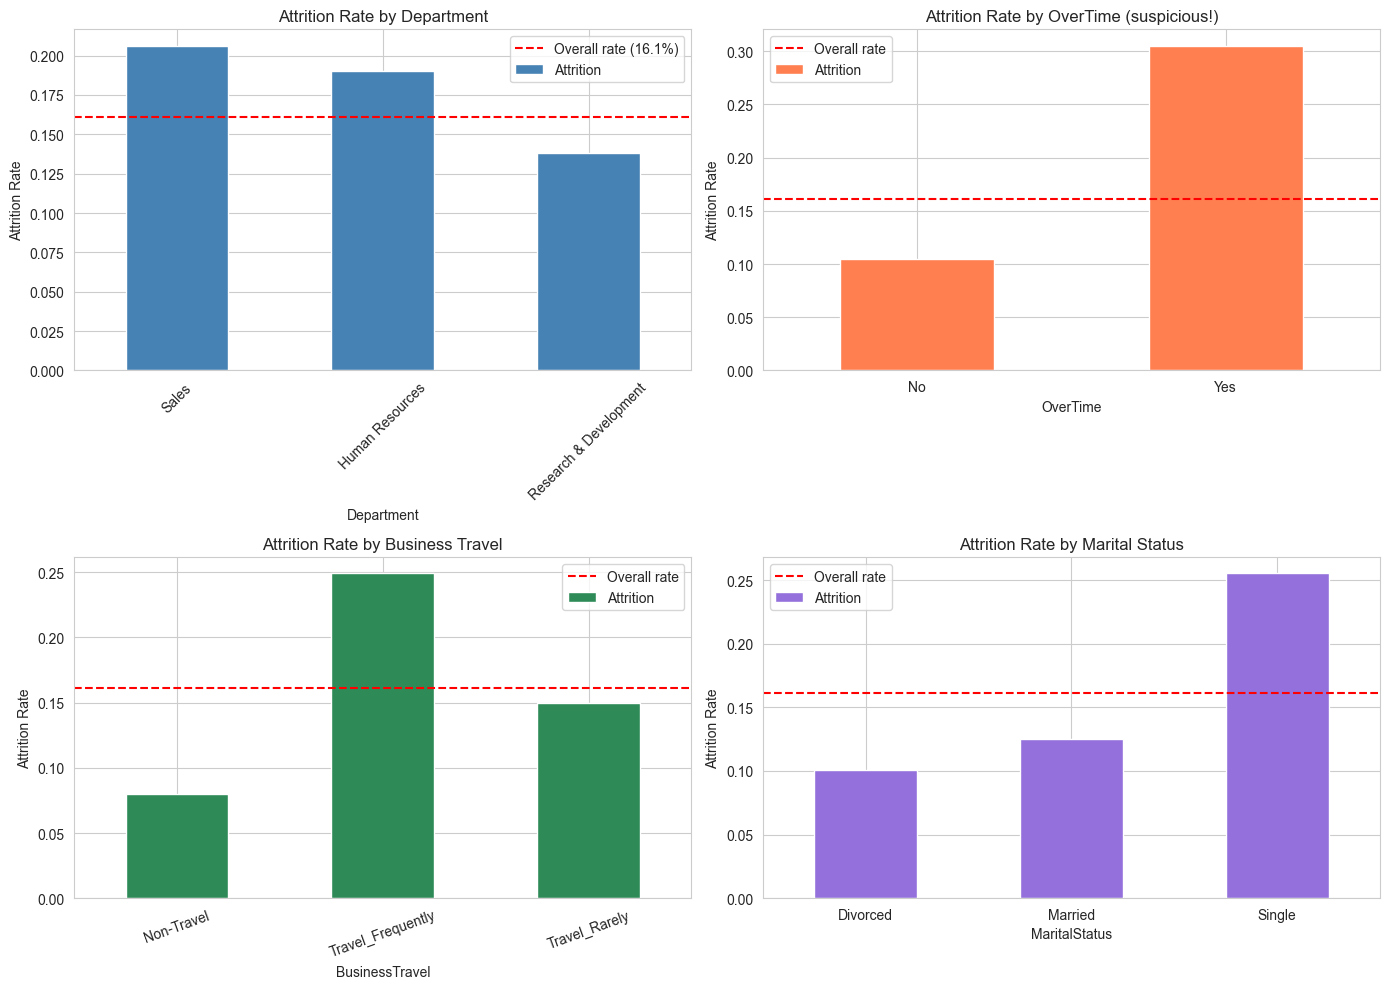


Key numbers:
OverTime=Yes attrition: 30.53%
OverTime=No attrition:  10.44%
Sales dept attrition:   20.63%


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Attrition by department, role, business travel, overtime
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Attrition by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
dept_attrition.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Attrition Rate by Department')
axes[0, 0].set_ylabel('Attrition Rate')
axes[0, 0].axhline(y=0.1612, color='red', linestyle='--', label='Overall rate (16.1%)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Attrition by OverTime — flagged as a suspicious predictor
ot_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean())
ot_attrition.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Attrition Rate by OverTime (suspicious!)')
axes[0, 1].set_ylabel('Attrition Rate')
axes[0, 1].axhline(y=0.1612, color='red', linestyle='--', label='Overall rate')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Attrition by Business Travel
bt_attrition = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x == 'Yes').mean())
bt_attrition.plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Attrition Rate by Business Travel')
axes[1, 0].set_ylabel('Attrition Rate')
axes[1, 0].axhline(y=0.1612, color='red', linestyle='--', label='Overall rate')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=20)

# 4. Attrition by Marital Status
ms_attrition = df.groupby('MaritalStatus')['Attrition'].apply(lambda x: (x == 'Yes').mean())
ms_attrition.plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Attrition Rate by Marital Status')
axes[1, 1].set_ylabel('Attrition Rate')
axes[1, 1].axhline(y=0.1612, color='red', linestyle='--', label='Overall rate')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'attrition_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey numbers:")
print(f"OverTime=Yes attrition: {df[df['OverTime']=='Yes']['Attrition'].eq('Yes').mean():.2%}")
print(f"OverTime=No attrition:  {df[df['OverTime']=='No']['Attrition'].eq('Yes').mean():.2%}")
print(f"Sales dept attrition:   {df[df['Department']=='Sales']['Attrition'].eq('Yes').mean():.2%}")

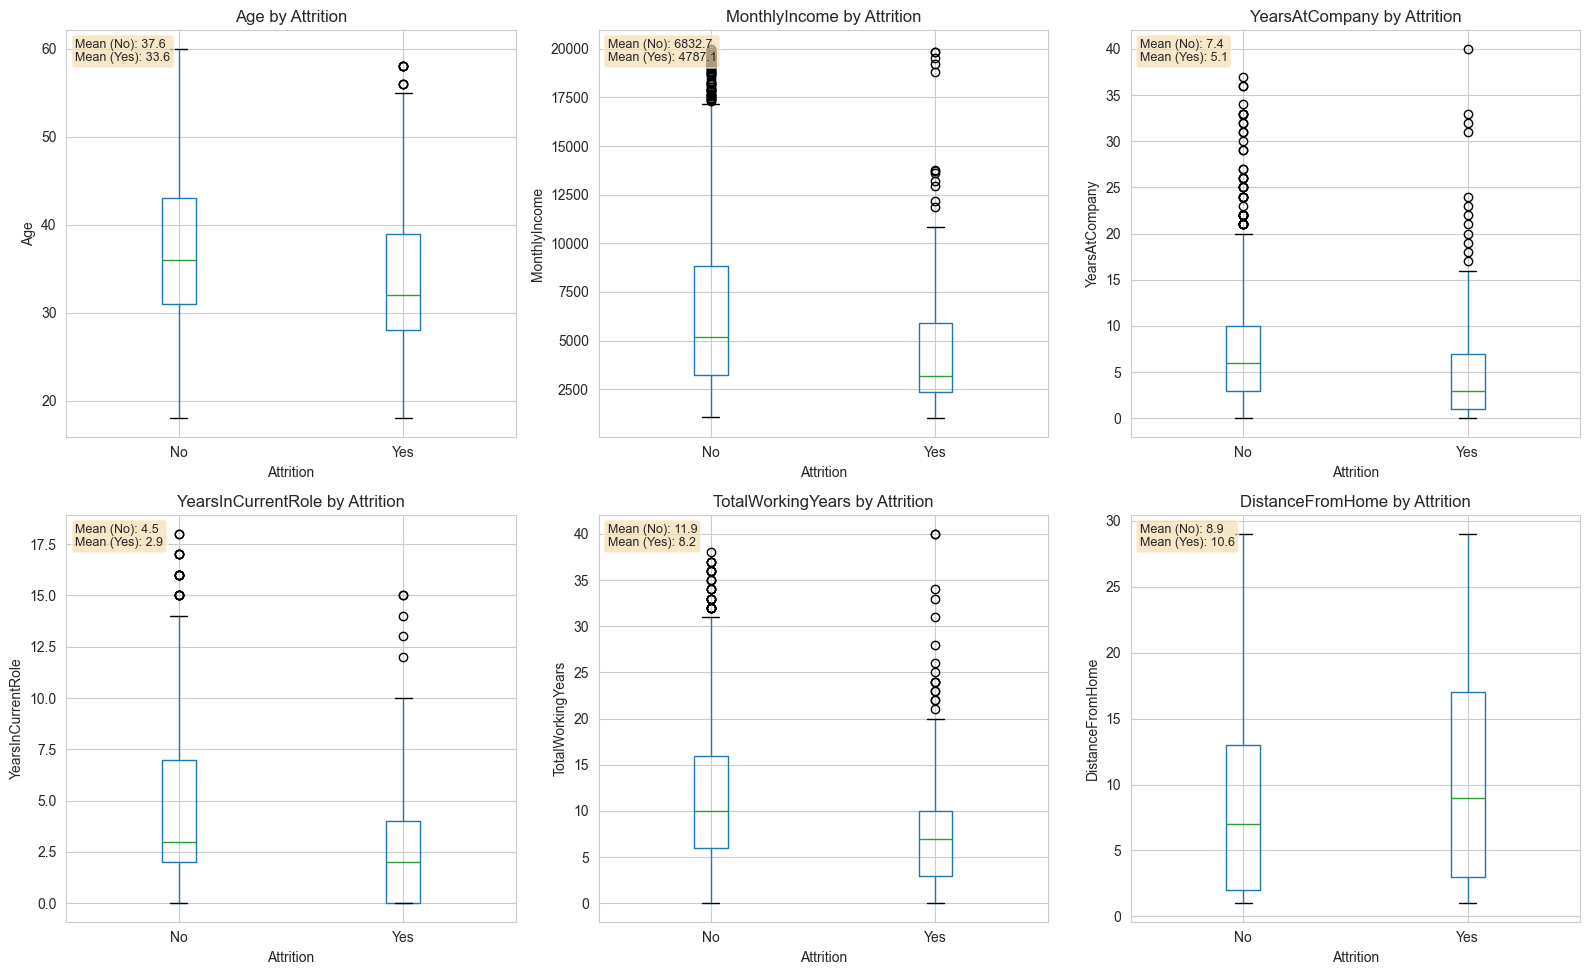


Mean values by attrition status:
Attrition               No     Yes
Age                   37.6    33.6
MonthlyIncome       6832.7  4787.1
YearsAtCompany         7.4     5.1
YearsInCurrentRole     4.5     2.9
TotalWorkingYears     11.9     8.2
DistanceFromHome       8.9    10.6


In [9]:
# Numeric variables — how do distributions differ between leavers and stayers?

numeric_to_inspect = ['Age', 'MonthlyIncome', 'YearsAtCompany', 
                      'YearsInCurrentRole', 'TotalWorkingYears', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_to_inspect):
    # Box plot: leavers vs stayers
    df.boxplot(column=col, by='Attrition', ax=axes[i])
    axes[i].set_title(f'{col} by Attrition')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel(col)
    
    # Add mean values as text
    means = df.groupby('Attrition')[col].mean()
    text = f"Mean (No): {means['No']:.1f}\nMean (Yes): {means['Yes']:.1f}"
    axes[i].text(0.02, 0.98, text, transform=axes[i].transAxes,
                 verticalalignment='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('')  # Remove default suptitle from boxplot
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'numeric_by_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nMean values by attrition status:")
print(df.groupby('Attrition')[numeric_to_inspect].mean().round(1).T)

Correlations with Attrition (sorted by absolute value):

TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
DistanceFromHome            0.078
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
NumCompaniesWorked          0.043
YearsSinceLastPromotion    -0.033
Education                  -0.031
MonthlyRate                 0.015
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
Name: Attrition, dtype: float64


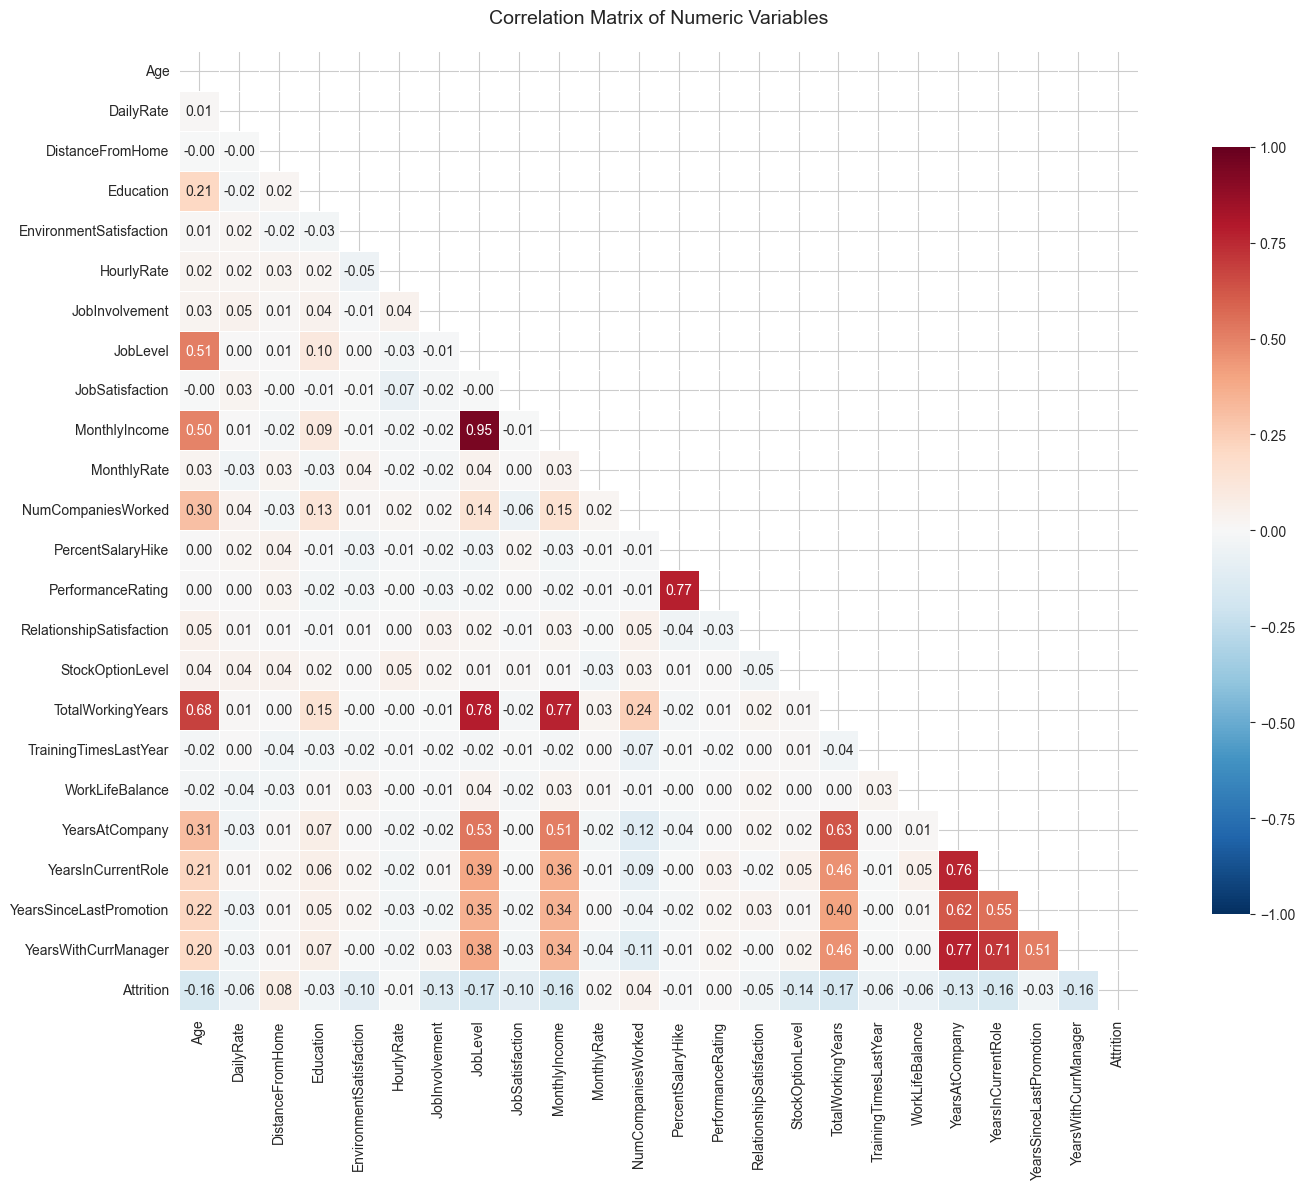

In [10]:
# Correlation heatmap — numeric features + attrition

# Encode attrition as 0/1 for correlation
df_numeric = df.select_dtypes(include='number').copy()
df_numeric['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Drop the constants and ID column from this view
cols_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
df_numeric = df_numeric.drop(columns=[c for c in cols_to_drop if c in df_numeric.columns])

# Correlation matrix
corr = df_numeric.corr()

# Show correlations with attrition specifically, sorted
print("Correlations with Attrition (sorted by absolute value):\n")
attrition_corr = corr['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print(attrition_corr.round(3))

# Heatmap of the full correlation matrix
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Variables', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Driver ranking — total and marginal impact

Following the co-working session: rank every variable by its impact on attrition, using both total impact (variance explained / range of effect) and marginal impact (per-unit effect from logistic regression).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Encode target as 0/1
y = (df['Attrition'] == 'Yes').astype(int)

# More robust split: use select_dtypes which handles all numeric types properly
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',
             'Attrition', 'PerformanceRating']

predictors_df = df.drop(columns=drop_cols)

numeric_cols = predictors_df.select_dtypes(include='number').columns.tolist()
categorical_cols = predictors_df.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric predictors ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\nCategorical predictors ({len(categorical_cols)}):")
print(categorical_cols)

Numeric predictors (22):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical predictors (7):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [15]:
# TOTAL IMPACT calculations
total_impact = []

# --- Categorical: use percentage-point range as total impact ---
for col in categorical_cols:
    rates = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean())
    pp_range = (rates.max() - rates.min()) * 100  # percentage points
    
    # Chi-squared p-value for statistical significance
    contingency = pd.crosstab(df[col], df['Attrition'])
    chi2, p_val, _, _ = chi2_contingency(contingency)
    
    total_impact.append({
        'variable': col,
        'type': 'categorical',
        'total_impact_pp': pp_range,
        'abs_correlation': np.nan,
        'chi2': chi2,
        'p_value': p_val
    })

# --- Numeric: use absolute correlation with attrition ---
for col in numeric_cols:
    corr = df[col].corr(y)
    total_impact.append({
        'variable': col,
        'type': 'numeric',
        'total_impact_pp': abs(corr) * 100,  # for comparable scale
        'abs_correlation': abs(corr),
        'chi2': np.nan,
        'p_value': np.nan
    })

total_df = pd.DataFrame(total_impact).sort_values('total_impact_pp', ascending=False)
print("Total impact ranking (top 15):\n")
print(total_df.head(15).to_string(index=False))

Total impact ranking (top 15):

            variable        type  total_impact_pp  abs_correlation      chi2      p_value
             JobRole categorical        37.259036              NaN 86.190254 2.752482e-15
            OverTime categorical        20.092414              NaN 87.564294 8.158424e-21
   TotalWorkingYears     numeric        17.106325         0.171063       NaN          NaN
            JobLevel     numeric        16.910475         0.169105       NaN          NaN
      BusinessTravel categorical        16.909747              NaN 24.182414 5.608614e-06
  YearsInCurrentRole     numeric        16.054500         0.160545       NaN          NaN
       MonthlyIncome     numeric        15.983958         0.159840       NaN          NaN
                 Age     numeric        15.920501         0.159205       NaN          NaN
YearsWithCurrManager     numeric        15.619932         0.156199       NaN          NaN
       MaritalStatus categorical        15.440172              NaN 4

In [16]:
# MARGINAL IMPACT via logistic regression
# One-hot encode categoricals; standardise numerics so coefficients are comparable

# Build the feature matrix
X_numeric = df[numeric_cols].copy()
X_categorical = pd.get_dummies(df[categorical_cols], drop_first=True)

# Standardise numeric features so coefficients are comparable across variables
scaler = StandardScaler()
X_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(X_numeric),
    columns=numeric_cols,
    index=df.index
)

X = pd.concat([X_numeric_scaled, X_categorical], axis=1)
print(f"Feature matrix shape: {X.shape}")

# Fit logistic regression with L2 regularisation (handles collinearity)
# class_weight='balanced' accounts for the 16% imbalance
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
model.fit(X, y)

# Extract coefficients
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

# Each coefficient = marginal effect on log-odds of attrition per 1 SD change (for numerics)
# or per category-difference vs the reference category (for categoricals)
print(f"\nModel fitted. Accuracy on training set: {model.score(X, y):.3f}")
print(f"(Note: training accuracy is biased — for indicative use only.)")

Feature matrix shape: (1470, 43)

Model fitted. Accuracy on training set: 0.778
(Note: training accuracy is biased — for indicative use only.)


In [17]:
# For each original variable, aggregate marginal effects across its dummies
def aggregate_marginal(variable_name, var_type):
    """Get marginal effect for a variable, handling categorical dummies."""
    if var_type == 'numeric':
        # Direct match
        row = coef_df[coef_df['feature'] == variable_name]
        return row['coefficient'].iloc[0] if len(row) else np.nan
    else:
        # Sum absolute values of dummy coefficients for this variable
        matching = coef_df[coef_df['feature'].str.startswith(variable_name + '_')]
        return matching['abs_coefficient'].sum() if len(matching) else np.nan

# Build the master ranking
ranking = []
for _, row in total_df.iterrows():
    var = row['variable']
    var_type = row['type']
    
    marginal = aggregate_marginal(var, var_type)
    
    ranking.append({
        'variable': var,
        'type': var_type,
        'total_impact_pp': round(row['total_impact_pp'], 2),
        'marginal_log_odds': round(marginal, 3) if not pd.isna(marginal) else np.nan,
        'marginal_abs': round(abs(marginal), 3) if not pd.isna(marginal) else np.nan,
        'p_value': round(row['p_value'], 4) if not pd.isna(row['p_value']) else np.nan
    })

ranking_df = pd.DataFrame(ranking)

# Rank by total impact and by marginal impact separately
ranking_df['total_rank'] = ranking_df['total_impact_pp'].rank(ascending=False, method='min').astype(int)
ranking_df['marginal_rank'] = ranking_df['marginal_abs'].rank(ascending=False, method='min').astype(int)

# Display sorted by total impact
print("DRIVER RANKING — Top 15 by total impact:\n")
print(ranking_df.sort_values('total_rank').head(15).to_string(index=False))

print("\n\nDRIVER RANKING — Top 15 by marginal impact:\n")
print(ranking_df.sort_values('marginal_rank').head(15).to_string(index=False))

DRIVER RANKING — Top 15 by total impact:

            variable        type  total_impact_pp  marginal_log_odds  marginal_abs  p_value  total_rank  marginal_rank
             JobRole categorical            37.26              5.218         5.218   0.0000           1              1
            OverTime categorical            20.09              1.711         1.711   0.0000           2              4
   TotalWorkingYears     numeric            17.11             -0.420         0.420      NaN           3             12
            JobLevel     numeric            16.91              0.124         0.124      NaN           4             25
      BusinessTravel categorical            16.91              2.482         2.482   0.0000           4              2
  YearsInCurrentRole     numeric            16.05             -0.501         0.501      NaN           6             10
       MonthlyIncome     numeric            15.98             -0.198         0.198      NaN           7             21
      

Saved: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/outputs/tables/ibm_driver_ranking.csv


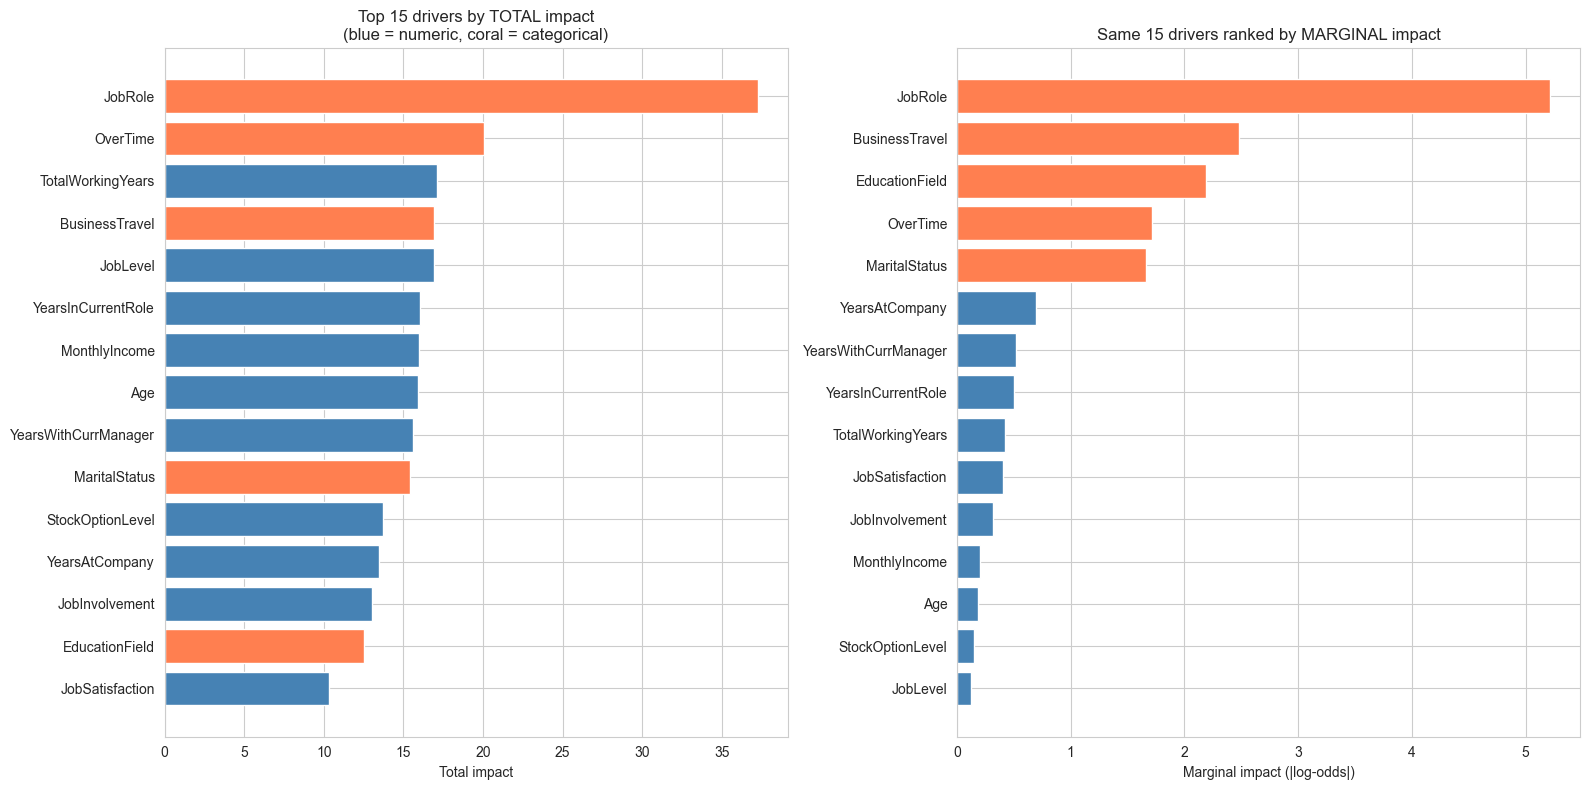

In [18]:
# Save the table
ranking_df.sort_values('total_rank').to_csv(
    PROJECT_ROOT / 'outputs' / 'tables' / 'ibm_driver_ranking.csv',
    index=False
)
print(f"Saved: {PROJECT_ROOT / 'outputs' / 'tables' / 'ibm_driver_ranking.csv'}")

# Visual — side-by-side bar chart of total vs marginal ranking
top_n = 15
top_vars = ranking_df.nsmallest(top_n, 'total_rank').sort_values('total_impact_pp')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: total impact
colors_total = ['steelblue' if t == 'numeric' else 'coral' for t in top_vars['type']]
axes[0].barh(top_vars['variable'], top_vars['total_impact_pp'], color=colors_total)
axes[0].set_xlabel('Total impact')
axes[0].set_title(f'Top {top_n} drivers by TOTAL impact\n(blue = numeric, coral = categorical)')

# Right: marginal impact (same variables, different metric)
top_vars_marginal = top_vars.sort_values('marginal_abs')
colors_marginal = ['steelblue' if t == 'numeric' else 'coral' for t in top_vars_marginal['type']]
axes[1].barh(top_vars_marginal['variable'], top_vars_marginal['marginal_abs'], color=colors_marginal)
axes[1].set_xlabel('Marginal impact (|log-odds|)')
axes[1].set_title(f'Same {top_n} drivers ranked by MARGINAL impact')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'driver_ranking.png', dpi=150, bbox_inches='tight')
plt.show()